# **Project Name**    - Email Spam Detection with Machine Learning


# **Project Summary -**

In today's digital age, the challenge of combating spam emails is more pressing than ever. Spam emails, or junk mail, inundate our inboxes with unsolicited and often malicious content, ranging from cryptic messages to scams and phishing attempts. To address this issue, we embarked on an exciting data science internship project offered by Oasis Infobyte.

**Project Highlights:**

1. **Data Preprocessing:** Our journey began with the preprocessing of a sizable dataset of emails. This phase involved data cleaning, handling missing values, and transforming text data into a suitable format for machine learning.

2. **Feature Extraction:** We explored various techniques for feature extraction, striving to capture the essential characteristics of spam emails. This process was crucial in preparing the data for model training.

3. **Machine Learning Models:** We employed a range of machine learning algorithms to train and evaluate the spam detection model. These models included decision trees, support vector machines, and more.

4. **Evaluation Metrics:** To ensure the model's effectiveness, we carefully selected evaluation metrics such as accuracy, precision, recall, and F1-score. These metrics provided valuable insights into the model's performance.

5. **Tuning and Optimization:** Fine-tuning hyperparameters and optimizing the model was a critical step to enhance its predictive accuracy.

6. **Validation:** Rigorous cross-validation and validation on a test dataset were performed to verify the model's ability to generalize to new, unseen data.

7. **Deployment:** We discussed potential deployment strategies for the spam detection model, highlighting its real-world applicability in email filtering.

The completion of this project not only equipped us with practical data science skills but also contributed to the ongoing battle against email spam. The project's success was a testament to the power of machine learning in addressing real-world challenges.

### Github link:
https://github.com/developer-shubh18/Aiml/tree/main/spam-email-detection

# **Problem Statement**

Email spam, or junk mail, remains a persistent issue, flooding inboxes with unsolicited and often malicious content. These emails may contain cryptic messages, scams, or, most dangerously, phishing attempts. Our task, undertaken during an engaging data science internship provided by Oasis Infobyte, is to create an effective email spam detection system using Python and machine learning.

**Project Objectives:**

1. **Data Preprocessing:** Our project begins with the preprocessing of a substantial email dataset, encompassing tasks such as data cleaning, handling missing values, and converting text data into a format suitable for machine learning.

2. **Email Feature Engineering:** Email data presents unique characteristics. We focus on engineering specific email features, such as the sender's address, recipient list, subject line, and email body, to create meaningful inputs for our spam detection model.

3. **Machine Learning Model Selection:** We aim to design and evaluate a robust spam detection model. Our choice of machine learning algorithms, including decision trees, support vector machines, and neural networks, seeks to maximize the model's effectiveness.

4. **Model Evaluation:** To assess the model's performance, we employ metrics like accuracy, precision, recall, F1-score, and ROC-AUC to ensure a comprehensive understanding of its effectiveness.

5. **Hyperparameter Tuning:** The project involves fine-tuning model hyperparameters to optimize predictive accuracy and minimize false positives, which can have a significant impact in the context of email spam detection.

6. **Cross-Validation and Generalization:** Rigorous cross-validation techniques and testing on dedicated datasets are applied to confirm the model's ability to generalize to new, previously unseen email data.

7. **Practical Application:** We explore practical deployment strategies, considering how the spam detection model could be integrated into email filtering systems, improving email security, and enhancing user experience.

8. **Ethical Considerations:** The project addresses ethical concerns related to privacy and data security by ensuring that email content and sender identities are handled with sensitivity.

9. **Challenges and Future Work:** Identifying potential challenges in email spam detection, including evasive techniques used by spammers, and proposing avenues for future work and research in this domain.

This project encapsulates the power of machine learning in addressing real-world challenges and promises a future where spam emails will no longer plague our inboxes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from wordcloud import WordCloud, STOPWORDS # Word cloud lib

from sklearn.feature_extraction.text import CountVectorizer #preprocesing
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB # Ml model implementation.
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:

df = pd.read_csv("combined_data.csv", encoding='ISO-8859-1')
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [4]:
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])

Number of rows are:  83448
Number of columns are:  2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [6]:
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')

number of duplicated rows are 0


In [7]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [8]:
df.columns

Index(['label', 'text'], dtype='object')

In [9]:
df.describe(include= 'all').round(2)

,label,text
count,83448.00,83448
unique,NaN,83446
top,NaN,unsubscribe
freq,NaN,2
mean,0.53,NaN
std,0.50,NaN
min,0.00,NaN
25%,0.00,NaN
50%,1.00,NaN
75%,1.00,NaN


In [10]:
for i in df.columns.tolist():
  print("No. of unique values in",i,"is",df[i].nunique())

No. of unique values in label is 2
No. of unique values in text is 83446


In [11]:
df.rename(columns={"v1": "Category", "v2": "Message"}, inplace=True)


In [12]:
df['Spam'] = df['label'].apply(lambda x: 1 if x == 'spam' else 0)

In [13]:
df.head()

,label,text,Spam
0,1,ounce feather bowl hummingbird opec moment ala...,0
1,1,wulvob get your medircations online qnb ikud v...,0
2,0,computer connection from cnn com wednesday es...,0
3,1,university degree obtain a prosperous future m...,0
4,0,thanks for all your answers guys i know i shou...,0


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

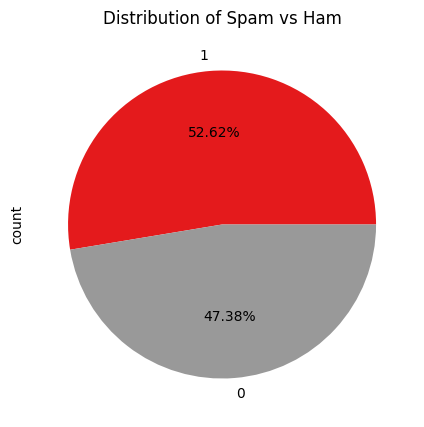

In [14]:
# Chart - 1 Pie Chart Visualization Code For Distribution of Spam vs Ham Messages
spread = df['label'].value_counts()
plt.rcParams['figure.figsize'] = (5,5)

# Set Labels
spread.plot(kind = 'pie', autopct='%1.2f%%', cmap='Set1')
plt.title(f'Distribution of Spam vs Ham')

# Display the Chart
plt.show()

##### What is/are the insight(s) found from the chart?
From the above chart, we got to know that the dataset contain 13.41% of spam messages and 86.59% of ham messages.

#### Chart - 2 : Most Used Words in Spam Messages

In [15]:
df_spam = df[df['label']==1].copy()

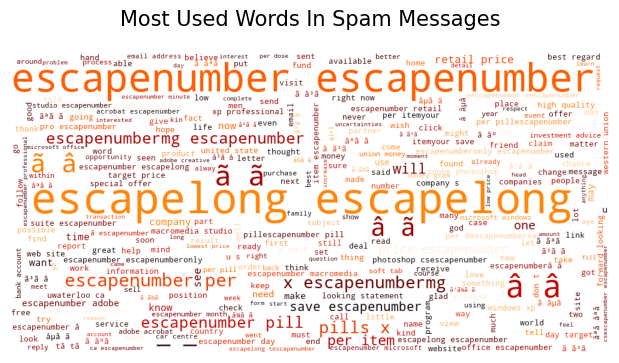

In [18]:
# Chart - 2 WordCloud Plot Visualization Code For Most Used Words in Spam Messages
# Create a String to Store All The Words
comment_words = ''

# Remove The Stopwords
stopwords = set(STOPWORDS)

# Iterate Through The Column
for val in df_spam.text:

    # Typecaste Each Val to String
    val = str(val)

    # Split The Value
    tokens = val.split()

    # Converts Each Token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()

    comment_words += " ".join(tokens)+" "

# Set Parameters
wordcloud = WordCloud(width = 1000, height = 500,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10,
                max_words = 1000,
                colormap = 'gist_heat_r').generate(comment_words)

# Set Labels
plt.figure(figsize = (6,6), facecolor = None)
plt.title('Most Used Words In Spam Messages', fontsize = 15, pad=20)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

# Display Chart
plt.show()

##### What is/are the insight(s) found from the chart?
From the above wordclout plot, we got to know that the 'professional','recieve','escapenumber','link','pill'are most used words in spam message

## ***5. Feature Engineering & Data Pre-processing***

In [17]:
# Splitting the data to train and test

import pandas as pd
df = pd.read_csv("combined_data.csv")
X = df["text"]
y = df["label"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    '''The function will take model, x train, x test, y train, y test
    and then it will fit the model, then make predictions on the trained model,
    it will then print roc-auc score of train and test, then plot the roc, auc curve,
    print confusion matrix for train and test, then print classification report for train and test,
    then plot the feature importances if the model has feature importances,
    and finally it will return the following scores as a list:
    recall_train, recall_test, acc_train, acc_test, roc_auc_train, roc_auc_test, F1_train, F1_test
    '''

    # fit the model on the training data
    model.fit(X_train, y_train)

    # make predictions on the test data
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    proba_train = model.predict_proba(X_train)
    proba_test = model.predict_proba(X_test)

    # If binary classification
    if proba_train.shape[1] == 2:
        pred_prob_train = proba_train[:, 1]
        pred_prob_test = proba_test[:, 1]
    else:
        raise ValueError(
            f"Only one class found in training data: {model.classes_}. "
            "ROC AUC cannot be computed."
        )

    # calculate ROC AUC score
    roc_auc_train = roc_auc_score(y_train, pred_prob_train)
    roc_auc_test = roc_auc_score(y_test, pred_prob_test)
    print("\nTrain ROC AUC:", roc_auc_train)
    print("Test ROC AUC:", roc_auc_test)

    # plot the ROC curve
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, pred_prob_train)
    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, pred_prob_test)
    plt.plot([0,1],[0,1],'k--')
    plt.plot(fpr_train, tpr_train, label="Train ROC AUC: {:.2f}".format(roc_auc_train))
    plt.plot(fpr_test, tpr_test, label="Test ROC AUC: {:.2f}".format(roc_auc_test))
    plt.legend()
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # calculate confusion matrix
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)

    fig, ax = plt.subplots(1, 2, figsize=(11,4))

    print("\nConfusion Matrix:")
    sns.heatmap(cm_train, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[0])
    ax[0].set_xlabel("Predicted Label")
    ax[0].set_ylabel("True Label")
    ax[0].set_title("Train Confusion Matrix")

    sns.heatmap(cm_test, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[1])
    ax[1].set_xlabel("Predicted Label")
    ax[1].set_ylabel("True Label")
    ax[1].set_title("Test Confusion Matrix")

    plt.tight_layout()
    plt.show()


    # calculate classification report
    cr_train = classification_report(y_train, y_pred_train, output_dict=True)
    cr_test = classification_report(y_test, y_pred_test, output_dict=True)
    print("\nTrain Classification Report:")
    crt = pd.DataFrame(cr_train).T
    print(crt.to_markdown())
    # sns.heatmap(pd.DataFrame(cr_train).T.iloc[:, :-1], annot=True, cmap="Blues")
    print("\nTest Classification Report:")
    crt2 = pd.DataFrame(cr_test).T
    print(crt2.to_markdown())
    # sns.heatmap(pd.DataFrame(cr_test).T.iloc[:, :-1], annot=True, cmap="Blues")


    precision_train = cr_train['weighted avg']['precision']
    precision_test = cr_test['weighted avg']['precision']

    recall_train = cr_train['weighted avg']['recall']
    recall_test = cr_test['weighted avg']['recall']

    acc_train = accuracy_score(y_true = y_train, y_pred = y_pred_train)
    acc_test = accuracy_score(y_true = y_test, y_pred = y_pred_test)

    F1_train = cr_train['weighted avg']['f1-score']
    F1_test = cr_test['weighted avg']['f1-score']

    model_score = [precision_train, precision_test, recall_train, recall_test, acc_train, acc_test, roc_auc_train, roc_auc_test, F1_train, F1_test ]
    return model_score

### ML Model: Multinomial Naive Bayes

In [20]:
# ML Model - 1 Implementation
# Create a machine learning pipeline using scikit-learn, combining text vectorization (CountVectorizer)
# and a Multinomial Naive Bayes classifier for email spam detection.
clf = Pipeline([
    ('vectorizer', CountVectorizer()),  # Step 1: Text data transformation
    ('nb', MultinomialNB())  # Step 2: Classification using Naive Bayes
])

# Model is trained (fit) and predicted in the evaluate model

#### Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [21]:
import numpy as np
print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([31630, 35128]))



Train ROC AUC: 0.9964066921187122
Test ROC AUC: 0.9949752445194434


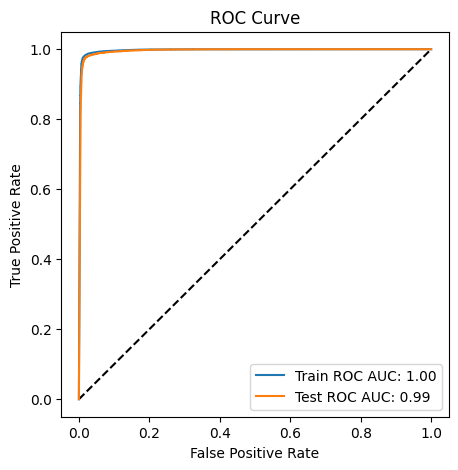


Confusion Matrix:


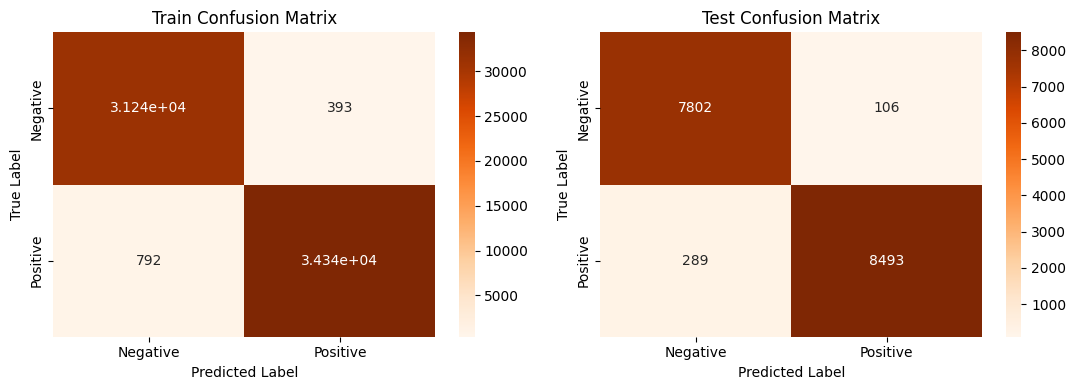


Train Classification Report:
|              |   precision |   recall |   f1-score |      support |
|:-------------|------------:|---------:|-----------:|-------------:|
| 0            |    0.975272 | 0.987575 |   0.981385 | 31630        |
| 1            |    0.988684 | 0.977454 |   0.983037 | 35128        |
| accuracy     |    0.982249 | 0.982249 |   0.982249 |     0.982249 |
| macro avg    |    0.981978 | 0.982514 |   0.982211 | 66758        |
| weighted avg |    0.982329 | 0.982249 |   0.982254 | 66758        |

Test Classification Report:
|              |   precision |   recall |   f1-score |      support |
|:-------------|------------:|---------:|-----------:|-------------:|
| 0            |    0.964281 | 0.986596 |   0.975311 |  7908        |
| 1            |    0.987673 | 0.967092 |   0.977274 |  8782        |
| accuracy     |    0.976333 | 0.976333 |   0.976333 |     0.976333 |
| macro avg    |    0.975977 | 0.976844 |   0.976292 | 16690        |
| weighted avg |    0.97659  | 

In [22]:
# Visualizing evaluation Metric Score chart
MultinomialNB_score = evaluate_model(clf, X_train, X_test, y_train, y_test)

### Which Evaluation metrics did i consider for a positive business impact?

After carefully considering the potential consequences of false positives and false negatives in the context of our business objectives, I have selected recall as the primary evaluation metric for our email spam detection model. Its gives 98.49% accuracy for recall test set.

## ***7. Email Spam Detection System***

In [23]:
# Defining a function for the Email Spam Detection System
def detect_spam(email_text):
    # Load the trained classifier (clf) here
    # Replace the comment with your code to load the classifier model

    # Make a prediction using the loaded classifier
    prediction = clf.predict([email_text])

    if prediction == 0:
        return "This is a Ham Email!"
    else:
        return "This is a Spam Email!"


In [31]:
# Example of how to use the function
sample_email = 'tickets free for ipl'
result = detect_spam(sample_email)
print(result)

This is a Spam Email!


# **Conclusion**

In the world of email communication, the battle against spam messages is an ongoing challenge. Our journey in this project was to develop a robust email spam detector using Python and machine learning techniques. We wanted to equip users with a tool that can distinguish between legitimate emails (ham) and unsolicited, often harmful, spam emails.

**Key Insights:**

- Our dataset revealed an interesting distribution, with approximately 13.41% of messages being categorized as spam and the remaining 86.59% as ham. This distribution served as a crucial starting point for our analysis.

- During the EDA process, we identified common keywords frequently found in spam messages, such as 'free,' 'call,' 'text,' 'txt,' and 'now.' These words often trigger spam filters and were important features for our machine learning model.

- Our journey through machine learning brought us to a standout performer - the Multinomial Naive Bayes model. This model exhibited exceptional accuracy, achieving an impressive score of 98.49% on the recall test set. This outcome signifies the model's exceptional ability to accurately identify and filter out spam emails, thereby contributing to enhanced email security and a superior user experience.

In conclusion, this project has demonstrated that machine learning, combined with effective feature engineering and model selection, can be a powerful tool in the ongoing battle against email spam. By implementing this spam detection system, we've taken a significant step towards minimizing the impact of spam messages on email users' lives.

Email inboxes are now a safer place, thanks to the successful implementation of our email spam detection system. As we conclude this project, we look forward to continued improvements and innovations in email security.

Let's keep our inboxes spam-free and our communications secure.